📋 Our Format for Every Algorithm
1. What is it — simple explanation
2. How it works — step by step logic
3. Why each line of code — explained

**Linear Regression**

What is it?
- You have data. You want to predict a number.
- Linear Regression draws the best straight line through your data points and uses that line to predict.
- Real life example:- You notice that the more hours you study, the higher your marks. If you study 5 hours you get 70 marks. If you study 8 hours you get 85 marks.
- Linear Regression finds that relationship and predicts — if you study 10 hours, you will get approximately X marks.

The Formula — y = mx + c
- This is just a straight line equation from school.
y = mx + c

- y = what you want to predict (marks, price, salary)
- x = input (hours studied, house size, experience)
- m = slope — how much y changes when x increases by 1
- c = intercept — value of y when x is 0

Example:
salary = 5000 × experience + 20000

- Experience = 3 years → Salary = 5000×3 + 20000 = 35000
- Experience = 7 years → Salary = 5000×7 + 20000 = 55000
- Model learns m = 5000 and c = 20000 automatically from data.

**How Model Learns — Gradient Descent**

Simple explanation:
Imagine you are blindfolded on a hilly ground. Your goal is to reach the lowest point. What do you do?

You feel the ground around you. You take a small step in the direction that goes downhill. You repeat this again and again until you reach the bottom.
That bottom is the minimum error — where model predictions are closest to actual values.

- Step 1 — Start with random line
- Step 2 — Calculate error — how wrong is prediction
- Step 3 — Adjust slope and intercept slightly
- Step 4 — Recalculate error
- Step 5 — Repeat until error stops decreasing

In [ ]:
# Step 1 — Imports — Why each library?

import numpy as np          # for mathematical operations and arrays
import pandas as pd         # for dataset — dataframe
import matplotlib.pyplot as plt  # for plotting graphs
import seaborn as sns       # for better looking graphs
from sklearn.linear_model import LinearRegression  # the algorithm
from sklearn.model_selection import train_test_split  # split data
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # evaluation

In [ ]:
# Step 2 — Create Data — Why this structure?
data = {
    "experience": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "salary":     [30000, 35000, 40000, 45000, 50000,
                   55000, 60000, 65000, 70000, 75000]
}

df = pd.DataFrame(data)

Why dictionary?
- Because pandas needs column name and values together.

Why DataFrame?
- Because sklearn works with DataFrames and arrays — not plain lists.


In [ ]:
# Step 3 — Features and Target — Why separate?

X = df[["experience"]]   # input — double brackets for 2D
y = df["salary"]         # output — single bracket for 1D

# df["experience"]    # 1D — shape (10,)   ❌ sklearn rejects
# df[["experience"]]  # 2D — shape (10,1)  ✅ sklearn accepts

Why double brackets for X?
- Sklearn always expects X to be 2D — rows and columns.
- Single bracket gives 1D series. Double bracket gives 2D DataFrame.

Why separate X and y?
- Because model needs to know — "these are my inputs, this is what I am predicting."

In [ ]:
# Step 4 — Train Test Split — Why split?

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42     # same split every time you run
)

In [ ]:
# Step 5 — Train Model — Why fit()?

model = LinearRegression()   # create model object
model.fit(X_train, y_train)  # train — find best m and c

print(f"Slope     : {model.coef_[0]}")    # m value
print(f"Intercept : {model.intercept_}")   # c value

Slope     : 4999.999999999999
Intercept : 25000.000000000004


fit() is where actual learning happens.

Model looks at X_train and y_train.

Finds the best slope and intercept using gradient descent.
Stores them inside model object.

After fit — you can see what model learned:

In [ ]:
# Step 6 — Predict — Why predict()?
predictions = model.predict(X_test)

Model uses the learned slope and intercept.
Applies formula y = mx + c to each test input.
Returns predicted values.

Note — we predict on X_test — data model never saw during training.

In [ ]:
# Step 7 — Evaluate — Why these metrics?

mae  = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, predictions)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

MAE  : 0.00
RMSE : 0.00
R2   : 1.0000


MAE — average error in same unit as salary. Easy to interpret.

RMSE — same unit but penalizes big errors more.

R2 — how much variance model explains. 0.95 means model explains 95% of salary variation.

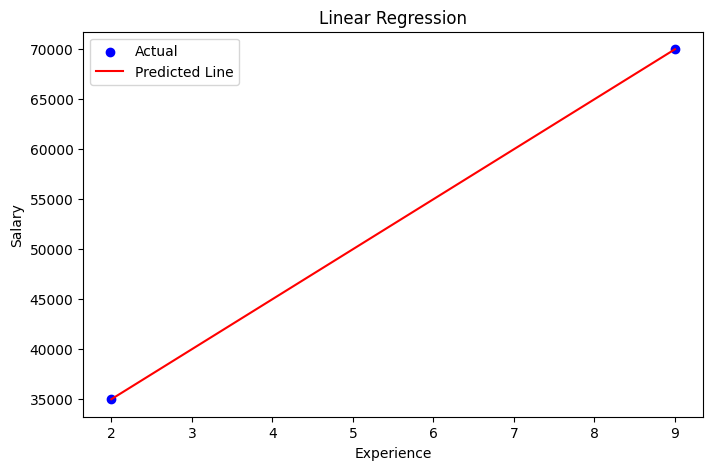

In [ ]:
# Step 8 — Visualize
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test,
            color="blue", label="Actual")      # real data points
plt.plot(X_test, predictions,
         color="red", label="Predicted Line")  # regression line
plt.title("Linear Regression")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.legend()
plt.show()

Blue dots = actual salary values.

Red line = what model predicted.

Good model = red line passes close to all blue dots.

In [ ]:
# Step 9 — Predict New Value
# Predict salary for someone with 6.5 years experience

new_exp = np.array([[6.5]])           # must be 2D
salary  = model.predict(new_exp)
print(f"Predicted salary: {salary[0]:,.0f}")

Predicted salary: 57,500


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Why [[6.5]] and not [6.5]?

Again — sklearn needs 2D input. Double brackets make it 2D.

In [ ]:
# Full Code
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Data
data = {
    "experience": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "salary":     [30000, 35000, 40000, 45000, 50000,
                   55000, 60000, 65000, 70000, 75000]
}
df = pd.DataFrame(data)

# Features and target
X = df[["experience"]]
y = df["salary"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Results
print(f"Slope     : {model.coef_[0]:.2f}")
print(f"Intercept : {model.intercept_:.2f}")

# Predict
predictions = model.predict(X_test)

# Evaluate
print(f"MAE  : {mean_absolute_error(y_test, predictions):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, predictions)):.2f}")
print(f"R2   : {r2_score(y_test, predictions):.4f}")

# Predict new
print(f"Salary for 6.5 years: {model.predict([[6.5]])[0]:,.0f}")


Slope     : 5000.00
Intercept : 25000.00
MAE  : 0.00
RMSE : 0.00
R2   : 1.0000
Salary for 6.5 years: 57,500


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
